# Лабораторна робота №3
## Візуалізація даних

**Датасет:** Iris з UCI Machine Learning Repository

In [2]:
# 1. Імпорт бібліотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# 2. Завантаження датасету Iris з UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

df = pd.read_csv(url, header=None, names=columns)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# 3. Загальна інформація про датасет
print('Розмір датасету:', df.shape)
print('Типи даних:')
print(df.dtypes)
print('Кількість пропущених значень:')
print(df.isna().sum())
print('Кількість дублікатів:', df.duplicated().sum())

Розмір датасету: (150, 5)
Типи даних:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object
Кількість пропущених значень:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Кількість дублікатів: 3


In [6]:
# 4. Data Cleaning
# У датасеті Iris немає пропущених значень, але перевіримо та очистимо можливі дублікати.
df_clean = df.drop_duplicates().copy()

# Робимо назви класів коротшими та зручнішими для графіків
df_clean['species'] = df_clean['species'].str.replace('Iris-', '', regex=False)

print('Розмір після очищення:', df_clean.shape)
df_clean.head()

Розмір після очищення: (147, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
# 5. Описова статистика числових атрибутів
df_clean.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


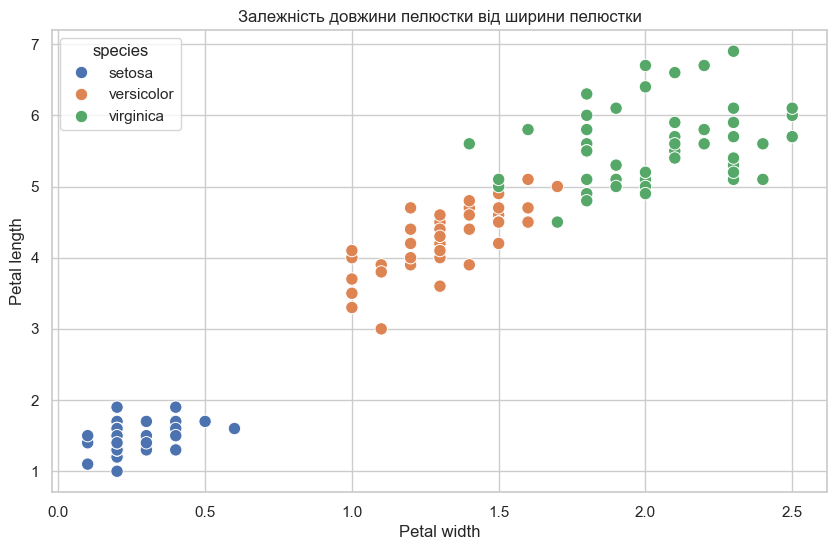

In [8]:
# 6. Графік залежності petal_length від petal_width — scatter plot
plt.figure()
sns.scatterplot(data=df_clean, x='petal_width', y='petal_length', hue='species', s=80)
plt.title('Залежність довжини пелюстки від ширини пелюстки')
plt.xlabel('Petal width')
plt.ylabel('Petal length')
plt.show()

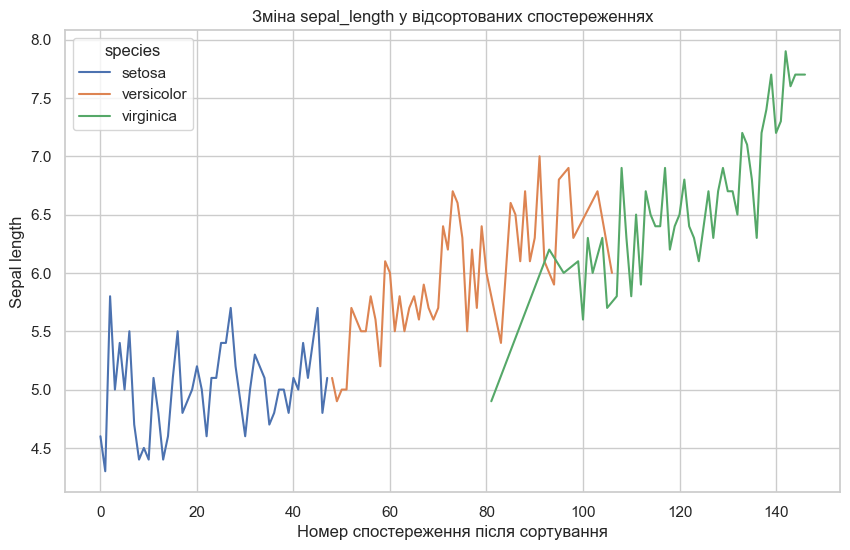

In [9]:
# 7. Line plot для sepal_length після сортування за petal_length
line_data = df_clean.sort_values('petal_length').reset_index(drop=True)

plt.figure()
sns.lineplot(data=line_data, x=line_data.index, y='sepal_length', hue='species')
plt.title('Зміна sepal_length у відсортованих спостереженнях')
plt.xlabel('Номер спостереження після сортування')
plt.ylabel('Sepal length')
plt.show()

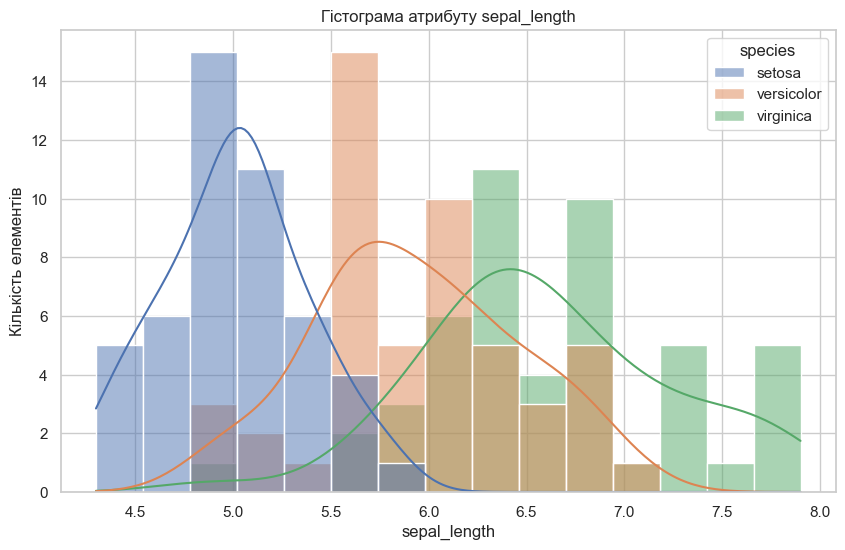

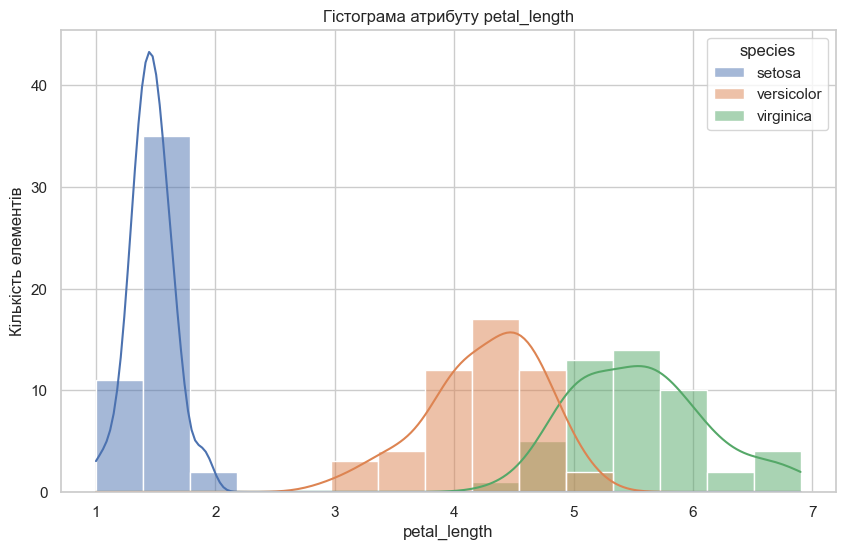

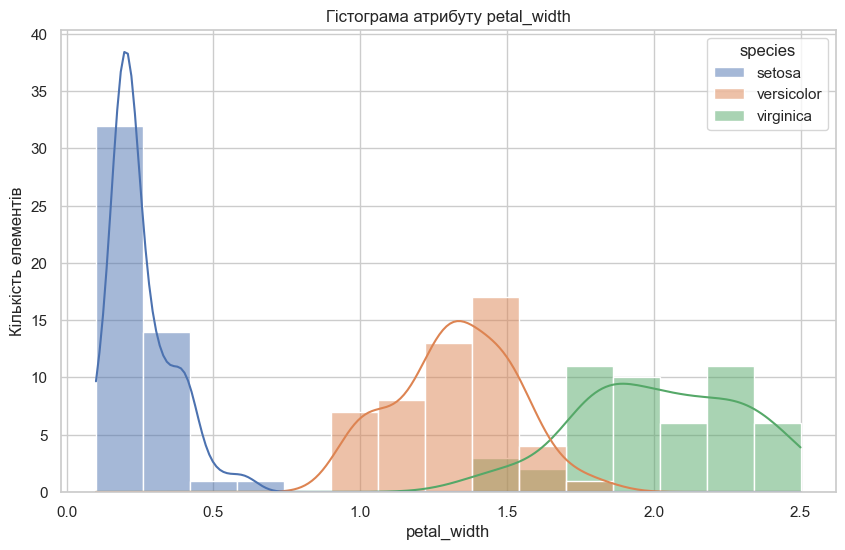

In [10]:
# 8. Гістограми трьох атрибутів
for column in ['sepal_length', 'petal_length', 'petal_width']:
    plt.figure()
    sns.histplot(data=df_clean, x=column, hue='species', kde=True, bins=15)
    plt.title(f'Гістограма атрибуту {column}')
    plt.xlabel(column)
    plt.ylabel('Кількість елементів')
    plt.show()

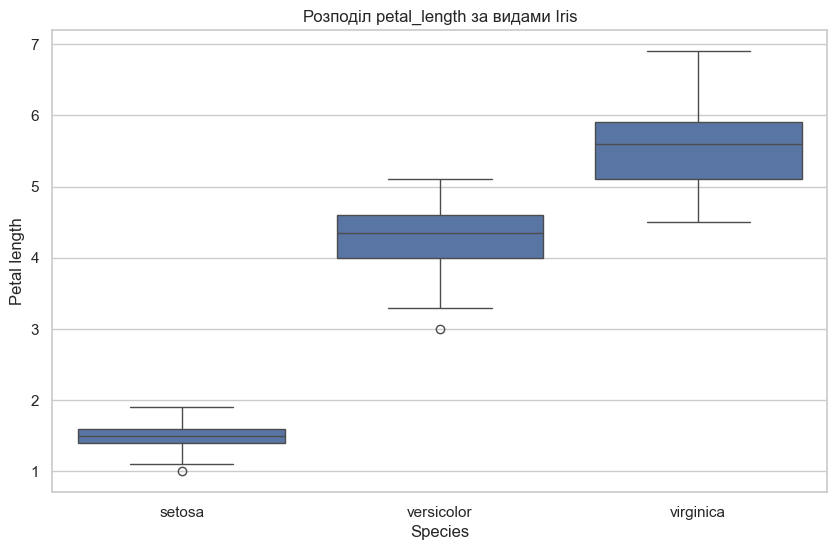

In [11]:
# 9. Boxplot: порівняння довжини пелюстки для різних класів
plt.figure()
sns.boxplot(data=df_clean, x='species', y='petal_length')
plt.title('Розподіл petal_length за видами Iris')
plt.xlabel('Species')
plt.ylabel('Petal length')
plt.show()

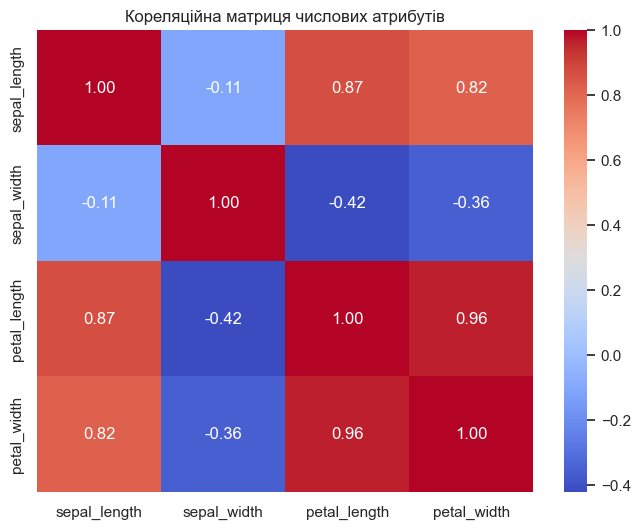

In [12]:
# 10. Кореляційна матриця числових атрибутів
numeric_df = df_clean.select_dtypes(include='number')
correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляційна матриця числових атрибутів')
plt.show()

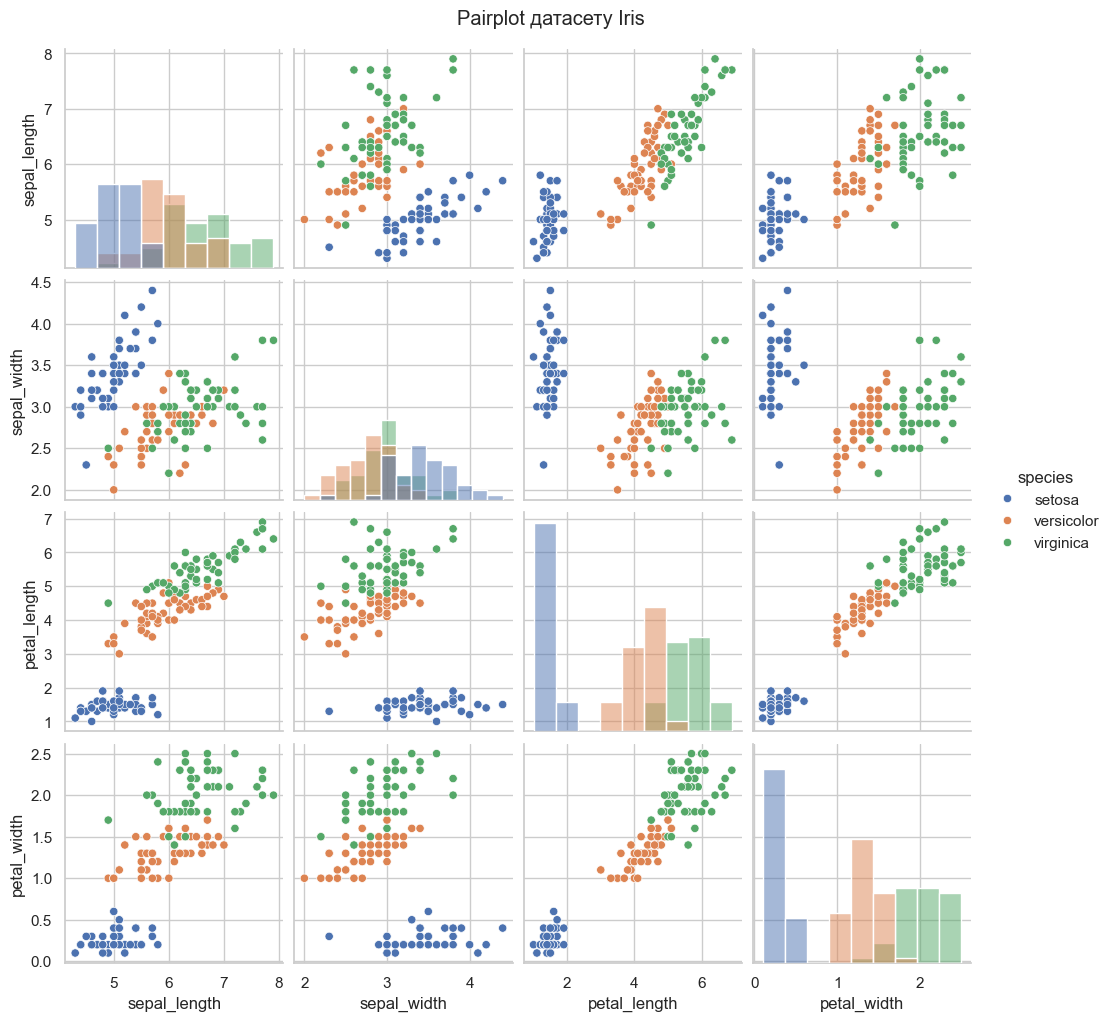

In [13]:
# 11. Pairplot для комплексного огляду залежностей
sns.pairplot(df_clean, hue='species', diag_kind='hist')
plt.suptitle('Pairplot датасету Iris', y=1.02)
plt.show()

## Висновки

1. Датасет Iris є багатовимірним і містить 4 числові real-атрибути та один категоріальний атрибут `species`.
2. Пропущені значення відсутні, тому основне очищення полягало у перевірці структури, типів даних та видаленні дублікатів.
3. Найкраще класи розділяються за ознаками `petal_length` і `petal_width`.
4. Кореляційна матриця показує сильний зв'язок між довжиною та шириною пелюстки.
5. Побудовані графіки дають корисну інформацію про розподіл, залежності та відмінності між класами датасету.